# 1.0.2 and 1.0.3: Exploratory Data Analysis (EDA)

## Dataset Overview

    - Source: Kaggle - US Building Materials Sales 2019-2024
    - Scope: Sales transactions of building materials with macroeconomic indicators
    - Objective: Understand data structure, entity relationships, and quality issues


In [ ]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Settings
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)

# Paths
DATA_DIR = Path('../data')
TRANSACTIONS_FILE = DATA_DIR / 'building_materials_transactions.csv'
MACRO_FILE = DATA_DIR / 'macro_drivers_weekly.csv'
DICT_FILE = DATA_DIR / 'data_dictionary_materials.csv'

print("Setup complete!")
print(f"Data directory: {DATA_DIR.absolute()}")

Setup complete!
Data directory: /Users/mnijonshuti/procurement-intelligence/data_engineer/notebooks/../data


## 1. Load Data

In [2]:
# Load datasets
df_transactions = pd.read_csv(TRANSACTIONS_FILE)
df_macro = pd.read_csv(MACRO_FILE)
df_dict = pd.read_csv(DICT_FILE)

print(f"Transactions shape: {df_transactions.shape}")
print(f"Macro drivers shape: {df_macro.shape}")
print(f"Data dictionary shape: {df_dict.shape}")

Transactions shape: (340000, 15)
Macro drivers shape: (313, 5)
Data dictionary shape: (15, 3)


## 2. Data Dictionary

In [3]:
df_dict

,column,type,description
0,date,date,Transaction week (Monday)
1,year,int,Year
2,month,int,Month (1-12)
3,week_of_year,int,ISO week number
4,region,string,"US census division (South_Atlantic, Pacific, M..."
5,product_category,string,"lumber, concrete_cement, roofing, drywall, ins..."
6,sku,string,Synthetic SKU code
7,channel,string,pro_dealer (contractor supply) or big_box_diy
8,customer_type,string,homebuilder / contractor / remodeler / homeown...
9,units,int,Units sold in the transaction


## 3. Transactions Dataset Overview

In [4]:
# Transactions overview
print(f"Shape: {df_transactions.shape[0]:,} rows x {df_transactions.shape[1]} columns")
print(f"Columns: {list(df_transactions.columns)}")
print()
print("Data types:")
print(df_transactions.dtypes)
print()
print("Sample data:")
print(df_transactions.head())

Shape: 340,000 rows x 15 columns
Columns: ['date', 'year', 'month', 'week_of_year', 'region', 'product_category', 'sku', 'channel', 'customer_type', 'units', 'unit_price', 'revenue', 'housing_starts_index', 'lumber_price_index', 'mortgage_rate']

Data types:
date                        str
year                      int64
month                     int64
week_of_year              int64
region                      str
product_category            str
sku                         str
channel                     str
customer_type               str
units                     int64
unit_price              float64
revenue                 float64
housing_starts_index    float64
lumber_price_index      float64
mortgage_rate           float64
dtype: object

Sample data:
         date  year  month  week_of_year              region product_category  \
0  2019-01-07  2019      1             2  East_North_Central          roofing   
1  2019-01-07  2019      1             2     Middle_Atlantic           

## 4. Macro Drivers Dataset Overview

In [5]:
# Macro drivers overview
print(f"Shape: {df_macro.shape[0]} rows x {df_macro.shape[1]} columns")
print(f"Date range: {df_macro['week'].min()} to {df_macro['week'].max()}")
print()
print("Columns:", list(df_macro.columns))
print()
print(df_macro.head())

Shape: 313 rows x 5 columns
Date range: 2019-01-07 to 2024-12-30

Columns: ['week', 'housing_starts_index', 'lumber_price_index', 'mortgage_rate', 'season_factor']

         week  housing_starts_index  lumber_price_index  mortgage_rate  \
0  2019-01-07                  96.4               388.0           3.95   
1  2019-01-14                  97.9               390.0           3.88   
2  2019-01-21                  97.2               402.0           3.89   
3  2019-01-28                  93.3               391.0           3.86   
4  2019-02-04                  92.7               379.0           3.83   

   season_factor  
0          0.581  
1          0.587  
2          0.598  
3          0.616  
4          0.639  


## 5. Cardinality Analysis

In [6]:
# Cardinality analysis
print("Unique values per column:")
cardinality_data = {col: df_transactions[col].nunique() for col in df_transactions.columns}
for col, count in cardinality_data.items():
    print(f"  {col:25} {count:>10,}")

Unique values per column:
  date                             313
  year                               6
  month                             12
  week_of_year                      53
  region                             9
  product_category                  10
  sku                           84,641
  channel                            2
  customer_type                      4
  units                          2,148
  unit_price                    23,423
  revenue                      160,438
  housing_starts_index             197
  lumber_price_index               143
  mortgage_rate                    170


## 6. Categorical Values

In [7]:
# Show unique values for categorical columns
cat_cols = ['region', 'product_category', 'channel', 'customer_type']

for col in cat_cols:
    print(f"{col}: {df_transactions[col].nunique()} unique values")
    print(f"  Values: {df_transactions[col].unique().tolist()}")

region: 9 unique values
  Values: ['East_North_Central', 'Middle_Atlantic', 'Pacific', 'West_South_Central', 'Mountain', 'South_Atlantic', 'West_North_Central', 'East_South_Central', 'New_England']
product_category: 10 unique values
  Values: ['roofing', 'lumber', 'concrete_cement', 'insulation', 'plumbing', 'windows_doors', 'paint_coatings', 'drywall', 'hardware_fasteners', 'electrical']
channel: 2 unique values
  Values: ['pro_dealer', 'big_box_diy']
customer_type: 4 unique values
  Values: ['remodeler', 'contractor', 'homeowner_diy', 'homebuilder']


## 7. Temporal Coverage

In [8]:
# Date range analysis
print(f"Transactions date range: {df_transactions['date'].min()} to {df_transactions['date'].max()}")
print(f"Unique dates (weeks): {df_transactions['date'].nunique()}")
print(f"Years: {sorted(df_transactions['year'].unique())}")
print(f"Total revenue: ${df_transactions['revenue'].sum():,.2f}")
print(f"Total units sold: {df_transactions['units'].sum():,}")

Transactions date range: 2019-01-07 to 2024-12-30
Unique dates (weeks): 313
Years: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Total revenue: $590,657,665.05
Total units sold: 47,939,567


## 8. Data Quality - Missing Values

In [9]:
# Check for missing values
print("======== Missing values in transactions ========")
print(df_transactions.isnull().sum())

print("\n======== Missing values in macro =========")
print(df_macro.isnull().sum())

======== Missing values in transactions ========
date                    0
year                    0
month                   0
week_of_year            0
region                  0
product_category        0
sku                     0
channel                 0
customer_type           0
units                   0
unit_price              0
revenue                 0
housing_starts_index    0
lumber_price_index      0
mortgage_rate           0
dtype: int64

======== Missing values in macro =========
week                    0
housing_starts_index    0
lumber_price_index      0
mortgage_rate           0
season_factor           0
dtype: int64


## 9. Data Quality Issues Analysis

In [10]:
# Data quality issues check
print("Checking derived columns...")
rev_check = (df_transactions['revenue'] == df_transactions['units'] * df_transactions['unit_price']).all()
print(f"  revenue = units × unit_price: {rev_check}")
print(f"  year/month/week_from_year derived from date: YES")

print("\nChecking duplicates...")
print(f"  Exact duplicates: {df_transactions.duplicated().sum()}")
business_key = ['date', 'region', 'product_category', 'sku', 'channel', 'customer_type']
key_dups = df_transactions.duplicated(subset=business_key).sum()
print(f"  By business key: {key_dups}")

print("\nChecking macro data coverage...")
trans_dates = set(df_transactions['date'].unique())
macro_dates = set(df_macro['week'].unique())
print(f"  Transaction weeks: {len(trans_dates)}")
print(f"  Macro weeks: {len(macro_dates)}")
print(f"  Missing: {len(trans_dates - macro_dates)}")

Checking derived columns...
  revenue = units × unit_price: False
  year/month/week_from_year derived from date: YES

Checking duplicates...
  Exact duplicates: 0
  By business key: 60

Checking macro data coverage...
  Transaction weeks: 313
  Macro weeks: 313
  Missing: 0


In [11]:
# Duplicate rows analysis
print("======= DUPLICATE ROWS EXAMPLES =======")

# Find duplicates by business key
business_key = ['date', 'region', 'product_category', 'sku', 'channel', 'customer_type']
duplicates = df_transactions[df_transactions.duplicated(subset=business_key, keep=False)]

print(f"Total duplicate rows: {len(duplicates)}")
print(f"Unique duplicate groups: {duplicates.groupby(business_key).ngroups}")

# Show first 10 duplicate rows
print(f"\nFirst 10 duplicate rows:")
display_cols = ['date', 'region', 'product_category', 'sku', 'channel', 'customer_type', 'units', 'revenue']
print(duplicates[display_cols].head(10).to_string())

# Check if duplicates have same values
sample_dup = duplicates.groupby(business_key).filter(lambda x: len(x) > 1).head(20)
print(f"\nAre duplicate values identical?")
key_example = duplicates[business_key].iloc[0].tolist()
print(f"Business key: {key_example}")
matching_rows = df_transactions[
    (df_transactions['date'] == key_example[0]) &
    (df_transactions['region'] == key_example[1]) &
    (df_transactions['product_category'] == key_example[2]) &
    (df_transactions['sku'] == key_example[3]) &
    (df_transactions['channel'] == key_example[4]) &
    (df_transactions['customer_type'] == key_example[5])
]
print(f"Rows with same key: {len(matching_rows)}")

======= DUPLICATE ROWS EXAMPLES =======
Total duplicate rows: 120
Unique duplicate groups: 60

First 10 duplicate rows:
             date              region product_category       sku      channel customer_type  units   revenue
2556   2019-02-04             Pacific         plumbing  PLU-3713  big_box_diy    contractor     14    393.96
2656   2019-02-04             Pacific         plumbing  PLU-3713  big_box_diy    contractor      8    224.64
5106   2019-03-04             Pacific          roofing  ROO-3664   pro_dealer    contractor      7    647.15
5644   2019-03-04             Pacific          roofing  ROO-3664   pro_dealer    contractor      8    857.76
14924  2019-05-13  West_South_Central  concrete_cement  CON-1121   pro_dealer   homebuilder    449   3672.82
15243  2019-05-13  West_South_Central  concrete_cement  CON-1121   pro_dealer   homebuilder    159   1354.68
21857  2019-06-17             Pacific           lumber  LUM-3074   pro_dealer     remodeler    137    883.65
22817  2

## 10. Outliers Analysis

In [12]:
# Check for outliers in macro indicators
print("======== OUTLIERS IN MACRO INDICATORS =======")
indicators = ['housing_starts_index', 'lumber_price_index', 'mortgage_rate']
for col in indicators:
    print(f"{col}:")
    print(f"  Min: {df_transactions[col].min():.2f}, Max: {df_transactions[col].max():.2f}")
    print(f"  Mean: {df_transactions[col].mean():.2f}, Std: {df_transactions[col].std():.2f}")
    
    mean_val = df_transactions[col].mean()
    std_val = df_transactions[col].std()
    outliers = df_transactions[(df_transactions[col] < mean_val - 3*std_val) | 
                               (df_transactions[col] > mean_val + 3*std_val)]
    print(f"  Outliers (|value - mean| > 3 sigma): {len(outliers)}\n")

======== OUTLIERS IN MACRO INDICATORS =======
housing_starts_index:
  Min: 92.70, Max: 127.70
  Mean: 107.82, Std: 7.98
  Outliers (|value - mean| > 3 sigma): 0

lumber_price_index:
  Min: 333.00, Max: 1548.00
  Mean: 497.29, Std: 252.13
  Outliers (|value - mean| > 3 sigma): 15978

mortgage_rate:
  Min: 2.84, Max: 7.63
  Mean: 5.52, Std: 1.74
  Outliers (|value - mean| > 3 sigma): 0



======= SEASONALITY ANALYSIS ========
season_factor in transactions: False
season_factor in macro: True

Season factor by month:
month
1     0.594
2     0.689
3     0.860
4     1.074
5     1.270
6     1.392
7     1.408
8     1.311
9     1.128
10    0.915
11    0.723
12    0.606
Name: season_factor, dtype: float64


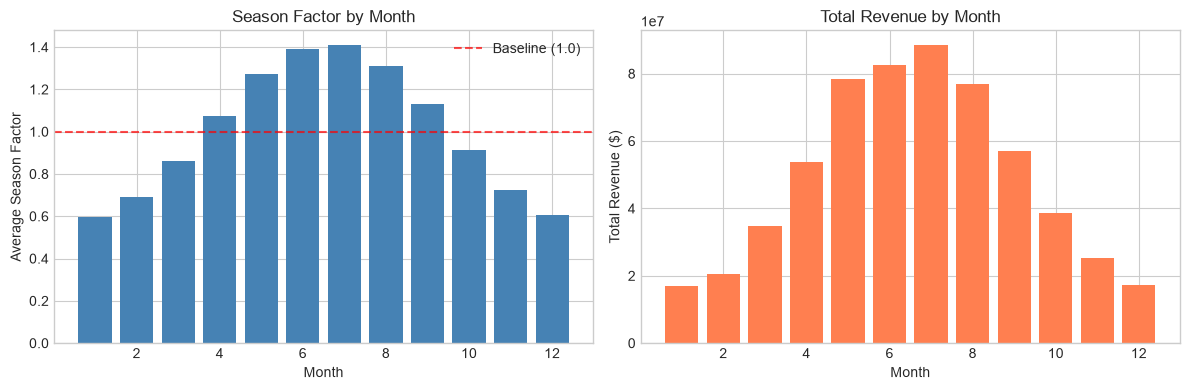

In [ ]:
# Seasonality analysis using season_factor
print("======= SEASONALITY ANALYSIS ========")

print(f"season_factor in transactions: {'season_factor' in df_transactions.columns}")
print(f"season_factor in macro: {'season_factor' in df_macro.columns}")

# Analyze seasonality from macro data
print("\nSeason factor by month:")
df_macro['month'] = pd.to_datetime(df_macro['week']).dt.month
season_by_month = df_macro.groupby('month')['season_factor'].mean()
print(season_by_month.round(3))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Season factor by month
axes[0].bar(season_by_month.index, season_by_month.values, color='steelblue')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Average Season Factor')
axes[0].set_title('Season Factor by Month')
axes[0].axhline(1.0, color='red', linestyle='--', alpha=0.7, label='Baseline (1.0)')
axes[0].legend()

# Revenue by month (aggregate)
monthly_revenue = df_transactions.groupby('month')['revenue'].sum()
axes[1].bar(monthly_revenue.index, monthly_revenue.values, color='coral')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Total Revenue ($)')
axes[1].set_title('Total Revenue by Month')

plt.tight_layout()
plt.show()

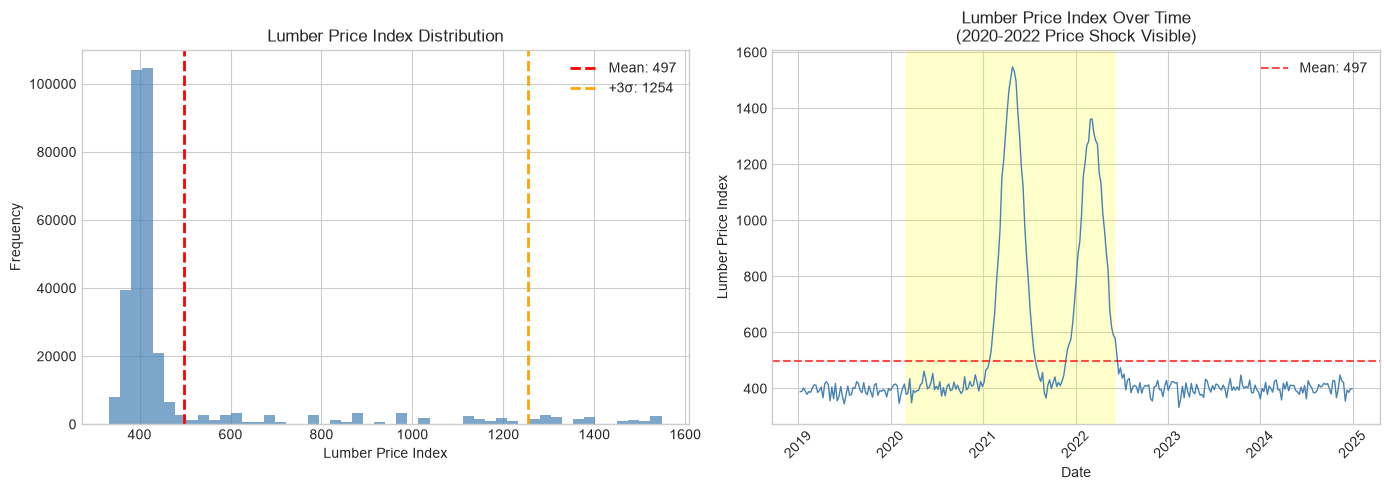

Lumber price spike: Max=1548.0 vs Mean=497


In [14]:
# Lumber price outlier visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Histogram with outlier threshold
ax1 = axes[0]
df_transactions['lumber_price_index'].hist(bins=50, ax=ax1, alpha=0.7, color='steelblue')
mean = df_transactions['lumber_price_index'].mean()
std = df_transactions['lumber_price_index'].std()
ax1.axvline(mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean:.0f}')
ax1.axvline(mean + 3*std, color='orange', linestyle='--', linewidth=2, label=f'+3σ: {mean + 3*std:.0f}')
ax1.set_title('Lumber Price Index Distribution', fontsize=12)
ax1.set_xlabel('Lumber Price Index')
ax1.set_ylabel('Frequency')
ax1.legend()

# 2. Time series - weekly average
ax2 = axes[1]
weekly_lumber = df_transactions.groupby('date')['lumber_price_index'].first().reset_index()
weekly_lumber['date_dt'] = pd.to_datetime(weekly_lumber['date'])
weekly_lumber = weekly_lumber.sort_values('date_dt')
ax2.plot(weekly_lumber['date_dt'], weekly_lumber['lumber_price_index'], linewidth=1.0, color='steelblue')
ax2.axhline(mean, color='red', linestyle='--', alpha=0.7, label=f'Mean: {mean:.0f}')
ax2.set_title('Lumber Price Index Over Time\n(2020-2022 Price Shock Visible)', fontsize=12)
ax2.set_xlabel('Date')
ax2.set_ylabel('Lumber Price Index')
ax2.tick_params(axis='x', rotation=45)
ax2.legend()

# Highlight 2020-2022
ax2.axvspan(pd.to_datetime('2020-03-01'), pd.to_datetime('2022-06-01'), 
            alpha=0.2, color='yellow', label='Price shock period')

plt.tight_layout()
plt.show()

print(f"Lumber price spike: Max={df_transactions['lumber_price_index'].max()} vs Mean={mean:.0f}")

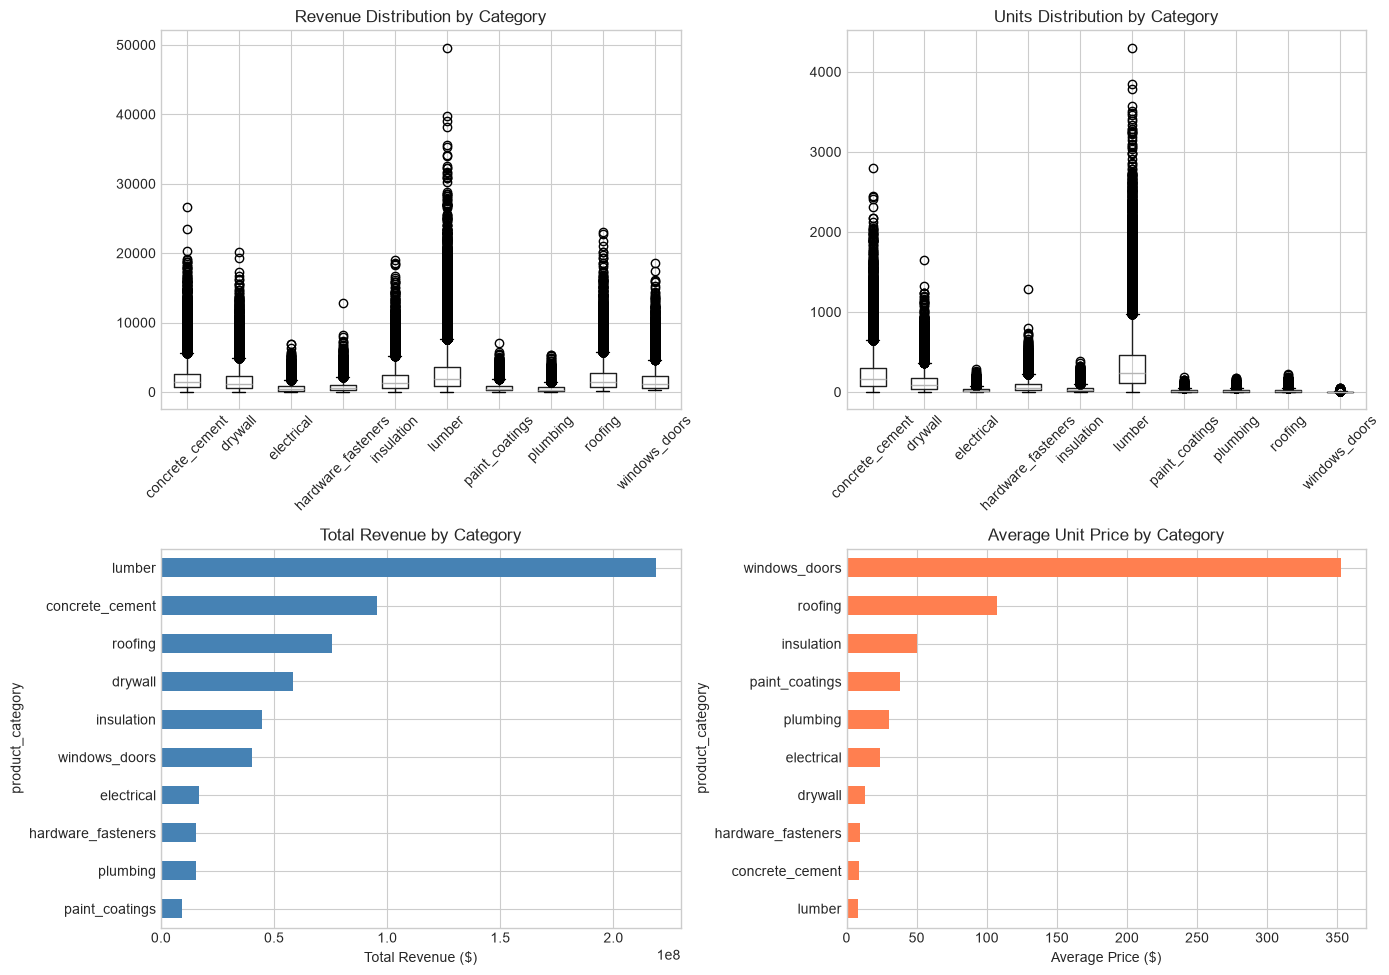

Category statistics:
                         revenue              units          unit_price  \
                             sum     mean       sum    mean         sum   
product_category                                                          
concrete_cement     9.564251e+07  1994.80  10931382  227.99   419777.14   
drywall             5.857470e+07  1718.14   4404722  129.20   454746.16   
electrical          1.700622e+07   622.76    711374   26.05   652680.94   
hardware_fasteners  1.566240e+07   774.37   1582878   78.26   200504.44   
insulation          4.449953e+07  1866.12    886322   37.17  1200086.29   
lumber              2.187610e+08  2694.30  27849059  342.99   646864.04   
paint_coatings      9.216932e+06   679.66    244000   17.99   512286.73   
plumbing            1.545233e+07   504.32    508133   16.58   932354.91   
roofing             7.547738e+07  2021.68    707192   18.94  3998967.06   
windows_doors       4.036463e+07  1692.22    114505    4.80  8418550.82   

   

In [15]:
# Revenue and Units distribution by category
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Revenue by category (boxplot)
ax1 = axes[0, 0]
df_transactions.boxplot(column='revenue', by='product_category', ax=ax1, rot=45)
ax1.set_title('Revenue Distribution by Category')
ax1.set_xlabel('')
plt.suptitle('')

# 2. Units by category (boxplot)
ax2 = axes[0, 1]
df_transactions.boxplot(column='units', by='product_category', ax=ax2, rot=45)
ax2.set_title('Units Distribution by Category')
ax2.set_xlabel('')
plt.suptitle('')

# 3. Total revenue by category (bar)
ax3 = axes[1, 0]
revenue_by_cat = df_transactions.groupby('product_category')['revenue'].sum().sort_values(ascending=True)
revenue_by_cat.plot(kind='barh', ax=ax3, color='steelblue')
ax3.set_title('Total Revenue by Category')
ax3.set_xlabel('Total Revenue ($)')

# 4. Average unit price by category
ax4 = axes[1, 1]
avg_price = df_transactions.groupby('product_category')['unit_price'].mean().sort_values(ascending=True)
avg_price.plot(kind='barh', ax=ax4, color='coral')
ax4.set_title('Average Unit Price by Category')
ax4.set_xlabel('Average Price ($)')

plt.tight_layout()
plt.show()

print("Category statistics:")
print(df_transactions.groupby('product_category')[['revenue', 'units', 'unit_price']].agg(['sum', 'mean']).round(2))

====== MACRO INDICATORS vs SALES CORRELATION ======

Correlation matrix:
                      revenue  units  housing_starts_index  \
revenue                 1.000  0.951                 0.040   
units                   0.951  1.000                 0.143   
housing_starts_index    0.040  0.143                 1.000   
lumber_price_index      0.149 -0.126                -0.381   
mortgage_rate           0.065  0.072                 0.294   
season_factor           0.933  0.942                -0.137   

                      lumber_price_index  mortgage_rate  season_factor  
revenue                            0.149          0.065          0.933  
units                             -0.126          0.072          0.942  
housing_starts_index              -0.381          0.294         -0.137  
lumber_price_index                 1.000         -0.163         -0.013  
mortgage_rate                     -0.163          1.000          0.017  
season_factor                     -0.013          0.01

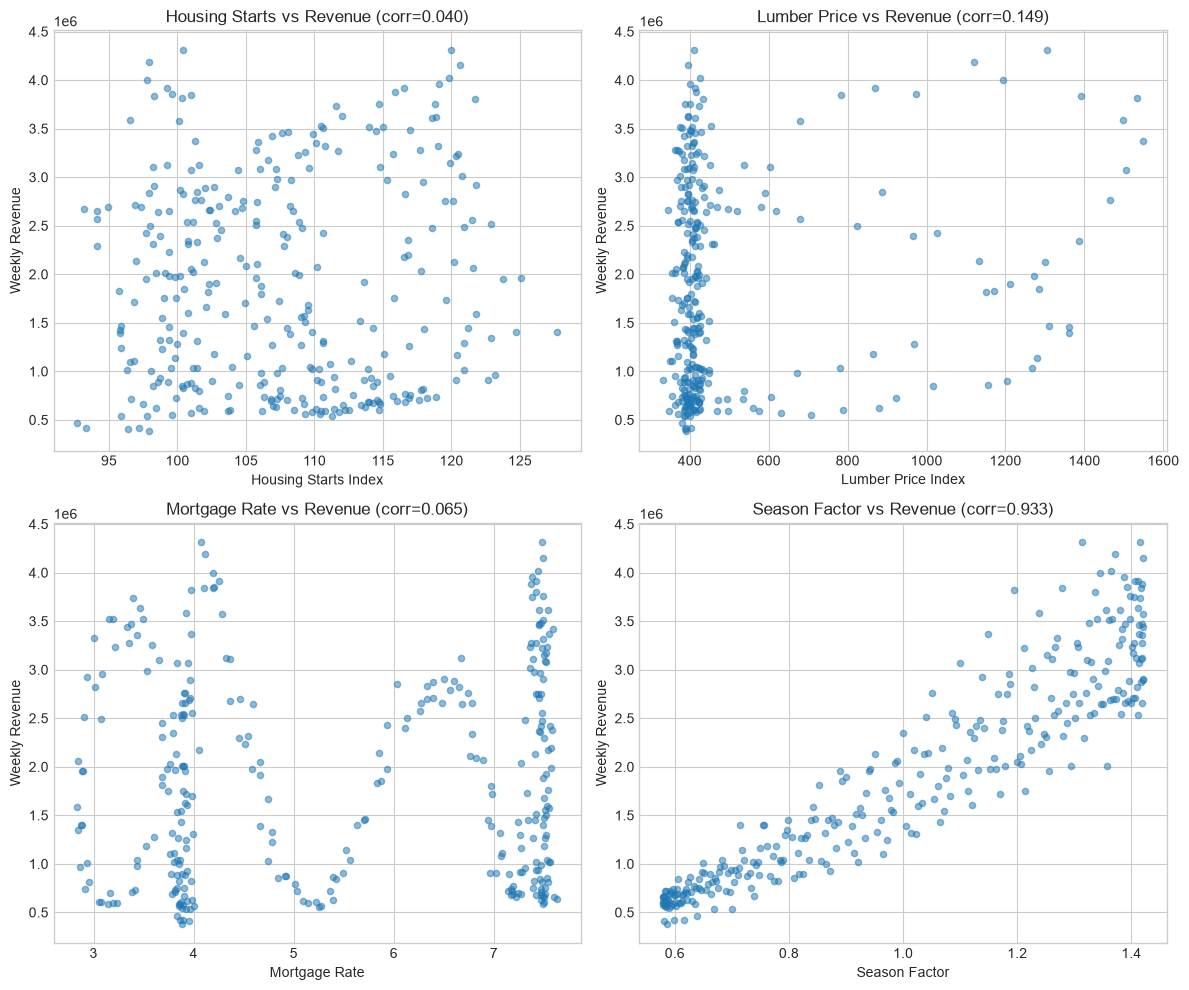


Key findings:
  - Housing Starts vs Revenue: 0.040
  - Lumber Price vs Revenue: 0.149
  - Mortgage Rate vs Revenue: 0.065


In [16]:
# Macro indicators correlation with sales
print("====== MACRO INDICATORS vs SALES CORRELATION ======")

# Aggregate only revenue and units by week
weekly_sales = df_transactions.groupby('date').agg({
    'revenue': 'sum',
    'units': 'sum'
}).reset_index()

# Merge with macro data - no duplicate column names
merged = weekly_sales.merge(df_macro, left_on='date', right_on='week', how='left')
merged = merged.drop(columns=['week'])  # Remove redundant date column

# Correlation
print("\nCorrelation matrix:")
corr_cols = ['revenue', 'units', 'housing_starts_index', 'lumber_price_index', 'mortgage_rate', 'season_factor']
print(merged[corr_cols].corr().round(3))

# Scatter plots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].scatter(merged['housing_starts_index'], merged['revenue'], alpha=0.5, s=20)
axes[0, 0].set_xlabel('Housing Starts Index')
axes[0, 0].set_ylabel('Weekly Revenue')
axes[0, 0].set_title(f'Housing Starts vs Revenue (corr={merged["housing_starts_index"].corr(merged["revenue"]):.3f})')

axes[0, 1].scatter(merged['lumber_price_index'], merged['revenue'], alpha=0.5, s=20)
axes[0, 1].set_xlabel('Lumber Price Index')
axes[0, 1].set_ylabel('Weekly Revenue')
axes[0, 1].set_title(f'Lumber Price vs Revenue (corr={merged["lumber_price_index"].corr(merged["revenue"]):.3f})')

axes[1, 0].scatter(merged['mortgage_rate'], merged['revenue'], alpha=0.5, s=20)
axes[1, 0].set_xlabel('Mortgage Rate')
axes[1, 0].set_ylabel('Weekly Revenue')
axes[1, 0].set_title(f'Mortgage Rate vs Revenue (corr={merged["mortgage_rate"].corr(merged["revenue"]):.3f})')

axes[1, 1].scatter(merged['season_factor'], merged['revenue'], alpha=0.5, s=20)
axes[1, 1].set_xlabel('Season Factor')
axes[1, 1].set_ylabel('Weekly Revenue')
axes[1, 1].set_title(f'Season Factor vs Revenue (corr={merged["season_factor"].corr(merged["revenue"]):.3f})')

plt.tight_layout()
plt.show()

print("\nKey findings:")
corr_rev_housing = merged['housing_starts_index'].corr(merged['revenue'])
corr_rev_lumber = merged['lumber_price_index'].corr(merged['revenue'])
corr_rev_mortgage = merged['mortgage_rate'].corr(merged['revenue'])
print(f"  - Housing Starts vs Revenue: {corr_rev_housing:.3f}")
print(f"  - Lumber Price vs Revenue: {corr_rev_lumber:.3f}")
print(f"  - Mortgage Rate vs Revenue: {corr_rev_mortgage:.3f}")

## 11. SKU Analysis

In [17]:
# SKU prefix to category mapping validation
print("======== SKU PREFIX vs PRODUCT CATEGORY MAPPING ==========")

prefix_to_category = {
    'ROO': 'roofing',
    'LUM': 'lumber',
    'CON': 'concrete_cement',
    'INS': 'insulation',
    'PLU': 'plumbing',
    'WIN': 'windows_doors',
    'PNT': 'paint_coatings',
    'DRY': 'drywall',
    'HRD': 'hardware_fasteners',
    'ELC': 'electrical'
}

# Extract SKU prefix
df_transactions['sku_prefix'] = df_transactions['sku'].str.split('-').str[0]

# Validate mapping
mismatches = []
for prefix, expected_cat in prefix_to_category.items():
    subset = df_transactions[df_transactions['sku_prefix'] == prefix]
    if len(subset) > 0:
        actual_cats = subset['product_category'].unique()
        if len(actual_cats) > 1 or (len(actual_cats) == 1 and actual_cats[0] != expected_cat):
            mismatches.append(f"{prefix} -> Expected: {expected_cat}, Got: {actual_cats}")

if mismatches:
    print("MISMATCHES FOUND:")
    for m in mismatches:
        print(f"  {m}")
else:
    print("All SKU prefixes match their product categories correctly!")

# Show mapping table
print("\nSKU prefix -> Category mapping:")
for prefix, cat in prefix_to_category.items():
    count = len(df_transactions[df_transactions['sku_prefix'] == prefix])
    print(f"  {prefix} -> {cat}: {count:,} rows")

======== SKU PREFIX vs PRODUCT CATEGORY MAPPING ==========
All SKU prefixes match their product categories correctly!

SKU prefix -> Category mapping:
  ROO -> roofing: 37,334 rows
  LUM -> lumber: 81,194 rows
  CON -> concrete_cement: 47,946 rows
  INS -> insulation: 23,846 rows
  PLU -> plumbing: 30,640 rows
  WIN -> windows_doors: 23,853 rows
  PNT -> paint_coatings: 0 rows
  DRY -> drywall: 34,092 rows
  HRD -> hardware_fasteners: 0 rows
  ELC -> electrical: 0 rows


In [18]:
# Analyze SKU structure
print("======== SKU ANALYSIS =====")
print(f"Total unique SKUs: {df_transactions['sku'].nunique():,}")

df_transactions['sku_prefix'] = df_transactions['sku'].str.split('-').str[0]
print(df_transactions['sku_prefix'].value_counts())

======== SKU ANALYSIS =====
Total unique SKUs: 84,641
sku_prefix
LUM    81194
CON    47946
ROO    37334
DRY    34092
PLU    30640
ELE    27308
WIN    23853
INS    23846
HAR    20226
PAI    13561
Name: count, dtype: int64


## 12. Entity Relationships Identifieds

| Entity | Type | Cardinality | Notes |
|--------|------|-------------|-------|
| `date` | Dimension | 313 unique | Links to macro_drivers |
| `region` | Dimension | 9 | US Census Division |
| `product_category` | Dimension | 10 | Building material categories |
| `sku` | Dimension | 84,641 | High cardinality - separate table |
| `channel` | Dimension | 2 | Sales channel |
| `customer_type` | Dimension | 4 | Customer segment |


```graph TD
┌─────────────────────────────────────────────────────────────────┐
│                    TRANSACTIONS (fact_sales)                    │
│  340,000 rows * 15 columns                                      │
│  Primary Key: отсутствует (surrogate needed)                    │
└─────────────────────────────────────────────────────────────────┘
         │                              │                      │
    date (FK)                      sku (FK)              other dims
         │                              │                      │
┌─────────────────┐          ┌─────────────────┐        ┌─────────────────┐
│  dim_date       │          │  dim_product    │        │  dim_...        │
│  313 weeks      │          │  84,641 SKUs    │        │  (low card)     │
└─────────────────┘          └─────────────────┘        └─────────────────┘
         │
    links to
         │
┌─────────────────┐
│  dim_macro      │
│  313 weeks      │
│  + season_factor│ <- MISSING in transactions!
└─────────────────┘
```

### Proposed Star Schema

```graph TD
                    ┌─────────────────────┐
                    │     fact_sales      │
                    │     (340K rows)     │
                    ├─────────────────────┤
                    │ transaction_id (PK) │
                    │ date_id (FK)        │
                    │ product_id (FK)     │
                    │ region_id (FK)      │
                    │ channel_id (FK)     │
                    │ customer_id (FK)    │
                    │ units               │
                    │ unit_price          │
                    │ revenue             │
                    └──────────┬──────────┘
                               │
      ┌────────────────────────┼────────────────────────┐
      │                        │                        │                              
┌──────────────┐      ┌────────────────┐      ┌──────────────┐
│  dim_date    │      │  dim_product   │      │  dim_macro   │
│  (313 rows)  │      │  (84,641 rows) │      │  (313 rows)  │
├──────────────┤      ├────────────────┤      ├──────────────┤
│ date_id (PK) │      │ product_id(PK) │      │ week_id (PK) │
│ date         │      │ sku            │      │ week         │
│ year         │      │ category       │      │ housing_idx  │
│ month        │      │ prefix         │      │ lumber_idx   │
│ week         │      │                │      │ mortgage_rt  │
│ quarter      │      │                │      │ season_factor│ <- INCLUDE!
│ is_holiday   │      │                │      └──────────────┘
└──────────────┘      └────────────────┘
      │
┌──────────────┐      ┌────────────────┐
│  dim_region  │      │  dim_channel   │
│  (9 rows)    │      │  (2 rows)      │
├──────────────┤      ├────────────────┤
│ region_id(PK)│      │ channel_id(PK) │
│ region_name  │      │ channel_name   │
│ division     │      │ channel_type   │
└──────────────┘      └────────────────┘

      ┌──────────────┐
      │ dim_customer │
      │  (4 rows)    │
      ├──────────────┤
      │ customer_id  │
      │ customer_type│
      │ segment      │
      └──────────────┘
```

## 13. Data Quality Issues Summary

    1. No Primary Key with Impact of Can't uniquely identify rows and the recommendation is to Add surrogate transaction_id
    2. 60 Business Key Duplicates (120 rows) with Impact of Data integrity and recommendation is to Use UPSERT (ON CONFLICT UPDATE)
    3. High Cardinality SKU (84,641) with the impact of Table size, performance and the recommendation is to Separate dim_product table
    4. Redundant Derived Columns with the impact of Storage waste and the recommendation is to Compute on-the-fly or in dim_date
    5. 15,978 Outliers in lumber_price with the impact of Analytics distortion	and the recommendation is to Validate or flag (price shock 2020-22)
    6. season_factor MISSING in transactions with impact that Can't analyze seasonality and the recommendation is to Add to dim_macro, join via date
    7. Macro indicators duplicated with the impact of Storage wast and it is recommended to Link via FK, don't embed in fact
    8. SKU prefix -> category mapping with the impact of Already consistent and it is recommended to Use for dim_product.prefix

## 14. Recommendations for Database Design

### Schema Design (3NF -> Star Schema):

1. **Fact Table: `fact_sales`**

         - `transaction_id` (PK, surrogate)
         - `date_id` (FK -> dim_date)
         - `product_id` (FK -> dim_product)
         - `region_id` (FK -> dim_region)
         - `channel_id` (FK -> dim_channel)
         - `customer_type_id` (FK -> dim_customer)
         - `units`, `unit_price`, `revenue`

2. **Dimension Tables:**

         - `dim_date`: date, year, month, week, quarter, is_holiday
         - `dim_product`: sku, category, subcategory, prefix
         - `dim_region`: region_name, census_division
         - `dim_channel`: channel_name, channel_type
         - `dim_customer`: customer_type, segment
         - `dim_macro`: week, housing_starts, lumber_index, mortgage_rate, season_factor

3. **Normalization/Denormalization Decision:**

         - Use 3NF for dimension tables (no redundant data)
         - Denormalized fact table for query performance
         - Macro indicators: linked via date, not embedded in fact


### Normalization Decision: Hybrid approach

``` graph TD
┌────────────────────────────────────────────────────────────────┐
│                    RECOMMENDED STRATEGY                        │
├────────────────────────────────────────────────────────────────┤
│  - Dimension Tables -> 3NF (no redundancy)                     │
│  - Fact Table -> Denormalized (for query performance)          │
│  - Macro data -> Separate table, link via date key             │
└────────────────────────────────────────────────────────────────┘
```

### ETL Pipeline Layers

```graph TD
┌─────────────┐     ┌─────────────┐     ┌─────────────┐
│   STAGING   │────>│    RAW      │────>│  PROCESSED  │
│  (CSV/JSON) │     │  (cleaned)  │     │  (modeled)  │
│             │     │             │     │             │
│ No changes  │     │ Validation  │     │ Star schema │
│ Raw data    │     │ Dedupe      │     │ Optimized   │
└─────────────┘     │ Error rows  │     │ for queries │
                    └─────────────┘     └─────────────┘
```

### SQL Decisions

```sql
-- 1. Surrogate keys for all dimensions
CREATE TABLE dim_product (
    product_id SERIAL PRIMARY KEY,
    sku VARCHAR(50) UNIQUE,
    category VARCHAR(50),
    prefix VARCHAR(10)
);

-- 2. UPSERT for handling duplicates
INSERT INTO fact_sales (...)
VALUES (...)
ON CONFLICT (date, region, sku, channel, customer_type)
DO UPDATE SET 
    units = fact_sales.units + EXCLUDED.units,  -- aggregate
    revenue = fact_sales.revenue + EXCLUDED.revenue;

-- 3. Error handling table
CREATE TABLE etl_errors (
    error_id SERIAL,
    source_file VARCHAR,
    raw_data JSONB,
    error_message TEXT,
    created_at TIMESTAMP DEFAULT NOW()
);

-- 4. season_factor INCLUDED in dim_macro
CREATE TABLE dim_macro (
    week_id SERIAL PRIMARY KEY,
    week DATE UNIQUE,
    housing_starts_index DECIMAL,
    lumber_price_index DECIMAL,
    mortgage_rate DECIMAL,
    season_factor DECIMAL  -- NOW INCLUDED!
);
```

### Data Validation Rules

|Check	|Rule	|Action on Fail|
|---|---|---|
|units >= 0	|Range check	|Move to etl_errors|
|unit_price > 0||Range check	|Move to etl_errors|
|lumber_price_index	< 2000 |(max observed)	|Flag/warn
|date IN dim_date	|FK check	|Reject row
|sku IN dim_product	|FK check	|Insert unknown SKU
